/var/folders/5z/rg0q4x2x5gl_n4zhlnzrcgxh0000gn/T/ipykernel_25880/3777408658.py:25: RuntimeWarning: Mean of empty slice
  df['mean'] = np.nanmean(W, axis=1)
/Users/joseph/miniconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



=== scan vertical (fixed ['ew', 'ns']) ===
  ew=0.028, ns=-0.28:  null vertical = -1.002 A,  width = 4.635 ms,  T = 6.39 uK

=== scan ew (fixed ['vertical', 'ns']) ===
  vertical=-1.005, ns=-0.28:  null ew = -0.014 A,  width = 4.373 ms,  T = 5.69 uK

=== scan ns (fixed ['vertical', 'ew']) ===
  vertical=-1.005, ew=0.0:  null ns = -0.242 A,  width = 4.368 ms,  T = 5.68 uK

best measured: vertical=-1.005, ew=0.0, ns=-0.28  ->  4.344 ms (5.61 uK)


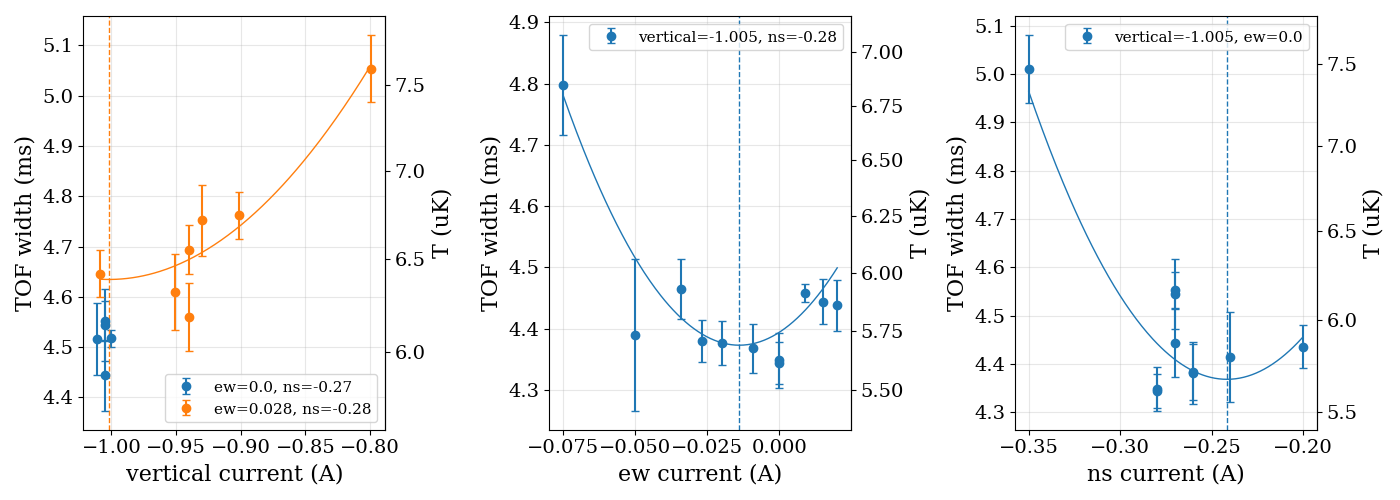

In [6]:
%matplotlib widget
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14); plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=11); plt.rc('figure', titlesize=18)

# ---- config ----
csv_path = 'nullingData_2026July15.csv'
coils    = ['vertical', 'ew', 'ns']       # first 3 cols = coil currents [A]
w_cols   = ['w1','w2','w3','w4','w5']      # the 5 TOF-width measurements [ms]
w_ref, T_ref = 4.3, 5.5                    # T[uK] = T_ref*(w/w_ref)**2
min_pts  = 3                               # min distinct pts to fit parabola
rnd      = 3                               # rounding for grouping fixed coils

w2T = lambda w: T_ref*(np.asarray(w)/w_ref)**2
T2w = lambda T: w_ref*np.sqrt(np.asarray(T)/T_ref)

# ---- load + reduce ----
df = pd.read_csv(csv_path)
df = df.rename(columns={df.columns[i]: coils[i] for i in range(3)})
W  = df[w_cols].to_numpy(float)
n  = np.sum(~np.isnan(W), axis=1)
df['mean'] = np.nanmean(W, axis=1)
df['sem']  = np.nanstd(W, axis=1, ddof=1) / np.sqrt(n)
df = df.dropna(subset=['mean'])
for c in coils: df[c] = df[c].round(rnd)

# ---- one panel per coil, parabola fit -> null current ----
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, scan in zip(axes, coils):
    fixed = [c for c in coils if c != scan]
    print(f'\n=== scan {scan} (fixed {fixed}) ===')
    for keys, g in df.groupby(fixed):
        g = g.sort_values(scan)
        if g[scan].nunique() < 2: continue
        x, y, s = g[scan].to_numpy(), g['mean'].to_numpy(), g['sem'].to_numpy()
        s = np.where((s > 0) & np.isfinite(s), s, 0.05)
        lbl = ', '.join(f'{f}={k}' for f, k in zip(fixed, np.atleast_1d(keys)))
        h = ax.errorbar(x, y, yerr=s, fmt='o', capsize=3, label=lbl)
        col = h[0].get_color()
        if g[scan].nunique() >= min_pts:
            a, b, c0 = np.polyfit(x, y, 2, w=1/s)
            if a > 0:
                xv = -b/(2*a); yv = a*xv**2 + b*xv + c0
                xs = np.linspace(x.min(), x.max(), 200)
                ax.plot(xs, a*xs**2 + b*xs + c0, '-', color=col, lw=1)
                ax.axvline(xv, color=col, ls='--', lw=1)
                print(f'  {lbl}:  null {scan} = {xv:.3f} A,  '
                      f'width = {yv:.3f} ms,  T = {w2T(yv):.2f} uK')
    ax.set_xlabel(f'{scan} current (A)')
    ax.set_ylabel('TOF width (ms)')
    ax.grid(alpha=0.3); ax.legend()
    sax = ax.secondary_yaxis('right', functions=(w2T, T2w))
    sax.set_ylabel('T (uK)')
fig.tight_layout()

best = df.loc[df['mean'].idxmin()]
print(f"\nbest measured: vertical={best['vertical']}, ew={best['ew']}, "
      f"ns={best['ns']}  ->  {best['mean']:.3f} ms ({w2T(best['mean']):.2f} uK)")